# Решение линейного стока (с использованием Ei)

Материалы курсов "Исследования скважин и пластов" и "Гидродинамические исследования скважин" в РГУ нефти и газа имени И.М.Губкина.

Версия 0.4 от 27.10.2025


---

Содержание

1. Уравнение фильтрации в радиальной форме 
    - Уравнение фильтрации, единицы измерения СИ
    - Уравнение фильтрации, практические метрические единицы изменения
    - Уравнение фильтрации, безразмерные переменные
2. Решение линейного стока
    - Учет скин-фактора для решения линейного стока
    - Построение графиков решения линейного стока  
        - Давление от расстояния для произвольного момента времени в безразмерных координатах
        - Безразмерное забойное давление от времени
        - Давление от расстояния для произвольного момента времени в размерных координатах
        - Забойное давление от времени
3. Радиус влияния
4. Расчет кривой восстановления давления 
    - Построение графиков распределения давления в пласте при восстановлении давления
5. Суперпозиция
    - Множественные запуски и остановки
    - Случай для линейного изменения дебита
    - Интергал Дюамеля



In [1]:
# импортируем библиотеки для расчетов

# numpy используем для работы с массивами и подготовки данных для построения графиков. 
# Также в некоторых функциях используем возможности векторных расчетов numpy
import numpy as np
# matplotlib используем для построения графиков
import matplotlib.pyplot as plt
# scipy.special используем как альтернативный вариант расчета специальных функций
import scipy.special as sp

# 1. Уравнение фильтрации в радиальной форме

## Уравнение фильтрации, единицы измерения СИ
Уравнение фильтрации для радиального потока в линеаризованном виде можно записать в виде


$$
\frac{\partial^2p}{\partial t^2} + \frac{1}{r}\frac{\partial p}{\partial r} = \frac{1}{\kappa}\frac{\partial p}{\partial t}
$$
где 
- $p(r,t)$ - давление в пласте, Па
- $r$ - расстояние, м
- $t$ - время, сек
- $\kappa$ -  коэффициент пьезопроводности 

$$
\kappa = \frac{k}{\varphi \mu\ c_t}
$$

Для построения решения надо задать начальное и граничные условия. Зададим условия для бесконечно малого радиуса скважины и бесконечного пласта. 

Начальное условие. До запуска скважины в момент времени  $t = 0$ давление в пласте равно начальному во всех точках $p=p_i$
$$ 
p(r,t) =  p_i , {t\le0}
$$

* условие постоянства дебита на скважине - граничное условие на скважине
$$ 
\lim_{r \to 0} { \frac{2\pi kh}{\mu B} \left( r \frac{\partial p}{\partial r} \right) } = -q  
$$

* условие на бесконечном расстоянии возмущения от скважине нет
$$ 
\lim_{r \to \infty}{ p(r,t)} =  p_i
$$

## Уравнение фильтрации, практические метрические единицы изменения
То же уравнение можно записать используя практические метрические единицы измерения
$$ 
\frac{\partial^2p}{\partial t^2} + \frac{1}{r}\frac{\partial p}{\partial r} = \frac{\varphi \mu c_t}{0.00036 k} \frac{\partial p}{\partial t} 
$$

Напомним, здесь
* $p(r,t)$ - давление в пласте, атм
* $t$ - время, час
* $k$ - проницаемость в направлении движения потока, мД
* $\mu$ - динамическая вязкость, сП
* $\phi$ - пористость, д.е.
* $c_t$ - сжимаемость, 1/атм
* $r$ - расстояние от центра, м


Начальное условие. До запуска скважины в момент времени  $t = 0$ давление в пласте равно начальному во всех точках $p=p_i$
$$ 
p(r,t) =  p_i , {t\le0}
$$

* условие постоянства дебита на скважине - граничное условие на скважине
$$ 
\lim_{r \to 0} { \frac{ kh}{ 18.42 \mu B} \left( r \frac{\partial p}{\partial r} \right) } = -q  
$$

* условие на бесконечном расстоянии возмущения от скважине нет
$$ 
\lim_{r \to \infty}{ p(r,t)} =  p_i
$$


## Уравнение фильтрации, безразмерные переменные
Часто для анализа уравнений неустановившейся фильтрации используются безразмерные переменные. Мы будем использовать переменные в виде:

$$ r_D = \frac{r}{r_w} \tag{2} $$
$$ t_D = \frac{0.00036 kt}{\phi \mu c_t r_w^2}  \tag{3}$$
$$ p_D = \frac{kh}{ 18.42 q_s B \mu} \left( p_i - p \right)  \tag{4} $$
$$ q_D = \frac{q}{ q_{ref} }$$


где в свою очередь 
* $q$ - дебит скважины на поверхности, приведенный к нормальным условиям, м^3^/сут
* $q_{ref}$ - референсный дебит скважины на поверхности, приведенный к нормальным условиям, м^3^/сут
* $\phi$ - пористость, доли единиц
* $\mu$ - вязкость нефти в пласте, сП
* $B$ - объемный коэффициент нефти, м^3^/м^3^
* $p_i$ - начальное давление в пласте, атм
* $p$ - давление забойное, атм
* $c_t$ - общая сжимаемость системы в пласте, 1/атм
* $k$ - проницаемость, мД
* $t$ -  время, час
* $r$ - расстояние от центра скважины, м
* $r_w$ - радиус скважины, м

Использование безразмерных переменных позволяет упростить уравнение фильтрации , которое примет вид

$$ 
\frac{\partial p_D}{ \partial t_D} = \dfrac{1}{r_D} \left[ \dfrac{\partial}{\partial r_D} \left( r_D \dfrac{ \partial p_D} {\partial r_D} \right) \right] 
\tag{5}
$$

Решение этого уравнения - функция безразмерного давления от безразмерных времени и расстояния $p_D(r_D, t_D) $


* начальное условие. До запуска скважины в момент времени  $t_D = 0$ давление в пласте равно начальному во всех точках $p=p_i$
$$ 
t_D < 0, p_D = 0
$$

* условие постоянства дебита на скважине - граничное условие на скважине
$$ 
\lim_{r_D \to 0} { r_D \frac{\partial p_D}{\partial r_D}} = q_D  
$$

* условие на бесконечном расстоянии возмущения от скважине нет
$$ 
r_D = \infty, p_D = 0  
$$

In [2]:
# определим безразмерные переменные

# определим функции для перевода размерных переменных в безразмерные и обратно
# пригодится потом для построения графиков и ведения расчетов

# при наименовании функций придерживаемся следующих соглашений
# сначала идет название того, что считаем
# в конце указывается размерность результата, если это уместно



def q_from_qd_sm3day(qd, q_ref_sm3day=1):
    """
    перевод безразмерного дебита скважины в размерный
    qd - безразмерный дебит скважины
    q_ref_sm3day - референсный дебит
    """
    return  qd * q_ref_sm3day 

def qd_from_q(q_sm3day, q_ref_sm3day=1):
    """
    перевод размерного дебита в безразмерные
    q_sm3day -  дебит скважины, ст. м3/сут
    q_ref_sm3day - референсный дебит
    """
    return q_sm3day / q_ref_sm3day

def r_from_rd_m(rd, rw_m=0.1):
    """
    перевод безразмерного расстояния в размерное
    rd -  безразмерное расстояние
    rw_m -  радиус скважины, м
    """
    return rd*rw_m

def rd_from_r(r_m, rw_m=0.1):
    """
    перевод размерного расстояния в безразмерное
    r_m - размерное расстояние, м
    rw_m - радиус скважины, м
    """
    return r_m/rw_m

def t_from_td_hr(td, k_mD=10, phi=0.2, mu_cP=1, ct_1atm=1e-5, rw_m=0.1):
    """
    перевод безразмерного времени в размерное, результат в часах
    td - безразмерное время
    k_mD - проницаемость пласта, мД
    phi - пористость, доли единиц
    mu_cP - динамическая вязкость флюида, сП
    ct_1atm - общая сжимаемость, 1/атм
    rw_m - радиус скважины, м
    """
    return td * phi * mu_cP * ct_1atm * rw_m * rw_m / k_mD / 0.00036

def td_from_t(t_hr, k_mD=10, phi=0.2, mu_cP=1, ct_1atm=1e-5, rw_m=0.1):
    """
    перевод размерного времени в безразмерное
    t_hr - размерное время, час
    k_mD - проницаемость пласта, мД
    phi - пористость, доли единиц
    mu_cP - динамическая вязкость флюида, сП
    ct_1atm - общая сжимаемость, 1/атм
    rw_m - радиус скважины, м
    """
    return  0.00036 * t_hr * k_mD / (phi * mu_cP * ct_1atm * rw_m * rw_m)

def p_from_pd_atma(pd, k_mD=10, h_m=10, q_ref_sm3day=1, b_m3m3=1.2, mu_cP=1, pi_atma=250):
    """
    перевод безразмерного давления в размерное, результат в абсолютных атмосферах
    pd - безразмерное давление
    k_mD - проницаемость пласта, мД
    h_m - мощность пласта, м
    q_ref_sm3day - дебит на поверхности, м3/сут в с.у.
    fvf_m3m3 - объемный коэффициент нефти, м3/м3
    mu_cP - динамическая вязкость флюида, сП
    pi_atma - начальное давление, абсолютные атм.
    """
    return pi_atma - pd * 18.42 * q_ref_sm3day * b_m3m3 * mu_cP / k_mD / h_m

def pd_from_p(p_atma, k_mD=10, h_m=10, q_ref_sm3day=1, b_m3m3=1.2, mu_cP=1, pi_atma=250):
    """
    перевод размерного давления в безразмерное
    p_atma - давление
    k_mD - проницаемость пласта, мД
    h_m - мощность пласта, м
    q_ref_sm3day - дебит на поверхности, м3/сут в с.у.
    fvf_m3m3 - объемный коэффициент нефти, м3/м3
    mu_cP - динамическая вязкость флюида, сП
    pi_atma - начальное давление, абсолютные атм.
    """
    return (pi_atma - p_atma) / (18.42 * q_ref_sm3day * b_m3m3 * mu_cP) * k_mD * h_m


# 2. Решение линейного стока 
Для решения уравнения фильтрации - линейного дифференциального уравнения в частных производных второго порядка необходимо задать начальные и граничные условия.
Самое простое решение можно получить для случая вертикальной скважины бесконечно малого радиуса запускающейся с постоянным дебитом. Условия соответствующие этому случаю можно выразить следующим образом


В этом случае решение может быть выражено через функцию интегральной экспоненты
$$ 
p_D(r_D,t_D) = - \frac{q_D}{2 } Ei \left(- \dfrac{ r_D^2}{4t_d} \right)  \tag{9}
$$

где -Ei(-x) - интегральная показательная функция.

Решение в размерных переменных можно записать как
$$
p\left(r,t\right)=p_i-\frac{18.42q_sB\mu}{kh}\left(-\frac{1}{2} Ei \left(-\frac{\varphi\mu c_tr^2}{0.00144kt}\right)\right) 
\tag{10}
$$



## Учет скин-фактора для решения линейного стока
Можно добавить скин-фактор

Получим в безразмерном виде решение для забойного давления с учетом скин-фактора

для положительного скин-фактора $S$
$$ 
p_D(r_D, t_D, q_D) = \begin{cases} 
     - \dfrac{q_D}{2 }  Ei \left(- \dfrac{ r_D ^2}{4t_d} \right)    & \text{если }  r_D > 1 \\[10pt]
     - \dfrac{q_D}{2 } \left[  Ei \left(- \dfrac{ 1}{4t_D} \right) + 2S \right]    & \text{если }  r_D = 1 
     \end{cases}
$$

для отрицательного скин-фактора $S$
$$ 
p_D(r_D, t_D, q_D) = \begin{cases} 
     - \dfrac{q_D}{2 }  Ei \left(- \dfrac{ r_D ^2}{4t_d} \right)    & \text{если } S<0  \text{ и } r_D > e^{-S} \\[10pt]
     - \dfrac{q_D}{2 }   Ei \left(- \dfrac{ {e^{-S}}^2}{4t_D} \right)    & \text{если } S<0  \text{ и } r_D \le e^{-S} 
     \end{cases}
$$

можно объединить формулы для положительного и отрицательного скин-факторов в одну более удобную для программной реализации

для положительного скин-фактора $S$
$$ 
p_D(r_D, t_D, q_D) = \begin{cases} 
     - \dfrac{q_D}{2 }  Ei \left(- \dfrac{ \left[ \max{ (r_D, e^{-S})} \right] ^2}{4t_D} \right)    & \text{если }  r_D > 1 \\[10pt]
     - \dfrac{q_D}{2 }  Ei \left(- \dfrac{ e^{-2S}}{4t_D} \right)     & \text{если }  r_D = 1 
     \end{cases}
$$

Эта единая формула автоматически описывает:
- дополнительное падение давления при $S > 0$,
- меньшее падение давления (повышение продуктивности) при $S < 0$.

Точность при $S > 0$: Замена $1 \to e^{-S}$ в аргументе $\mathrm{Ei}$ даёт точное совпадение с классической формулой $-\dfrac{q_D}{2}\left[\mathrm{Ei}\!\left(-\dfrac{1}{4t_D}\right) + 2S\right]$  в логарифмическом приближении $\mathrm{Ei}(-x) \approx \gamma + \ln x$ (актуально при $t_D \lesssim 0{,}01$). Для практических расчётов различие пренебрежимо мало.


В программной реализаци расчета безразменого решения линейного стока, для обеспечения векторных расчетов с библиотекой `numpy` вместо явных условных переходов можно использовать функцию Хевисайда.

In [3]:
# Решение линейного стока уравнения фильтрации
def pd_line_source_ei(td, rd, qd=1, skin=0):
    """
    Решение линейного стока уравнения фильтрации (безразмерная форма).
    
    Parameters
    ----------
    td : array-like
        Безразмерное время.
    rd : array-like
        Безразмерное расстояние от стока.
    qd : float, optional
        Безразмерный дебит (по умолчанию 1.0).
    skin : float, optional
        Скин-фактор (по умолчанию 0.0).
    
    Returns
    -------
    pd : ndarray
        Безразмерное давление.
    """
    # оценим приведенный радиус скважины
    rd_eff = np.exp(-skin) * np.heaviside(-skin, 0) + np.heaviside(skin, 1)
    # преобразуем входные радиусы в приведенные с учетом величины скин-фактора
    rd_calc = rd * np.heaviside(rd - rd_eff, 0) + np.exp(-skin) * np.heaviside(rd_eff - rd, 1)
    # исключим нулевые величины времени, чтобы избежать деления на ноль
    td_safe = np.where(td > 0, td, 1)
    pd = - qd / 2 / np.pi * ( 1 / 2  * sp.expi(-rd_calc**2 / 4 / td_safe)  )
    # в конце обнулим результаты для нулевых моментов времени
    return  pd * np.heaviside(td, 0)

Расчеты в размерных переменных зависят от свойств пласта - проницаемости, мощности, пористости, сжимаемости породы и свойств флюида - вязкости, сжимаемости флюида. Общая сжимаемость системы включает как свойства пласта так и флюида. Эти параметры постоянно необходимы для проведения расчетов. Для удобства можно объединить их в рамках одного объекта - `ReservoirModel`

In [4]:
class ReservoirModel:
    def __init__(self) -> None:
        self.k_mD = 10      # проницаемость, мД
        self.phi = 0.2      # пористость, д.ед.
        self.h_m = 10       # мощность пласта, м
        self.mu_cP = 1      # вязкость флюида, сП
        self.b_m3m3 = 1.2   # объемный коэффициент флюида, м3/М3
        self.ct_1atm = 4e-5 # общая сжимаемость системы
        self.rw_m = 0.1     # радиус скважины
        self.p_init_atma = 250 # начальное пластовое давление
        self.skin = 0       # скин-фактор скважины

In [5]:
def p_line_source_ei_atma(t_hr, r_m, q_sm3day=1, res=None):
    """
    Решение линейного стока уравнения фильтрации
    rd - безразмерное расстояние
    t_hr - безразмерное время
    qd - безразмерный дебит
    skin - величина скин-фактора
    """
    if res is None:
        res = ReservoirModel()
    td = td_from_t(t_hr, res.k_mD, res.phi, res.mu_cP, res.ct_1atm, res.rw_m)
    rd = rd_from_r(r_m, res.rw_m)
    qd = qd_from_q(q_sm3day)
    pd = pd_line_source_ei(td, rd, qd, res.skin)
    return p_from_pd_atma(pd, res.k_mD, res.h_m, 1, res.b_m3m3, res.mu_cP, res.p_init_atma)



## Построение графиков решения линейного стока 

### Давление от расстояния для произвольного момента времени в безразмерных координатах

Пример показывает как построить распределение давления для заданного момента времени. Помните что тут безразмерное давление и время. Для построения графика используется логарифмическое распределение значений расстояния, так как около нуля требуется больше точек для отображения из за значительного изменения функции.

скин-фактор = -3


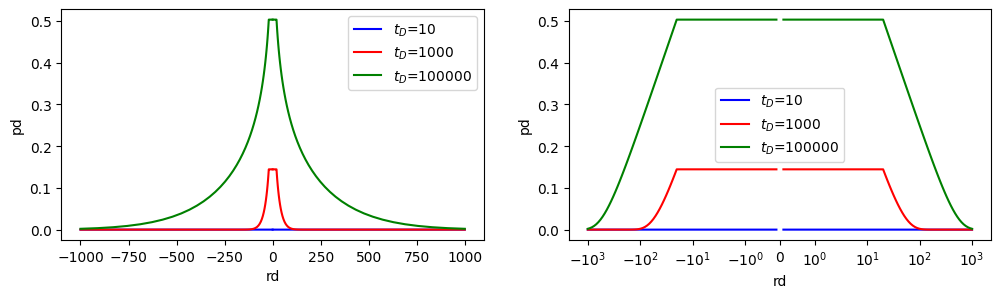

скин-фактор = 0


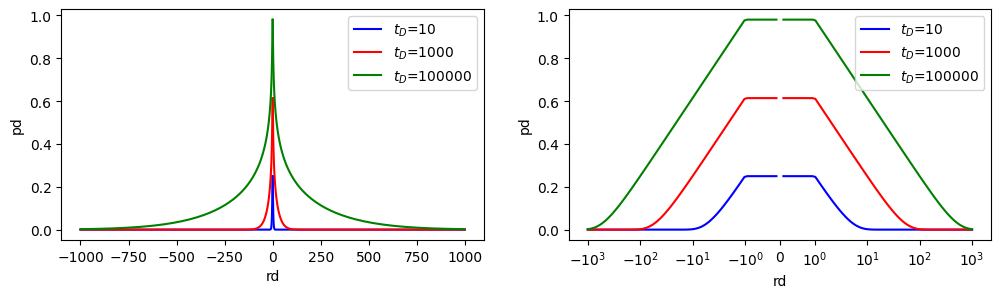

скин-фактор = 3


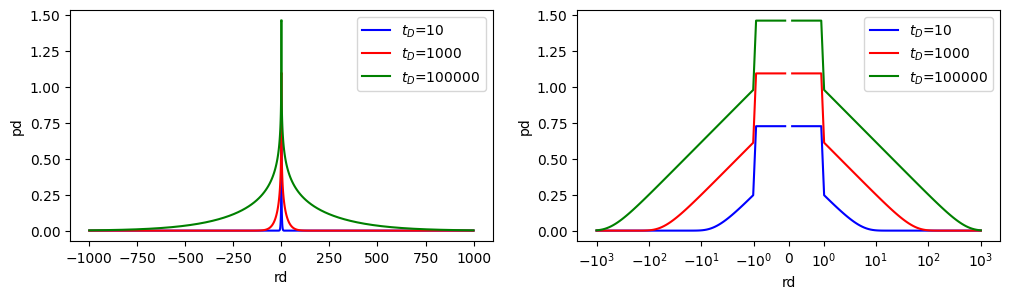

In [6]:
rd_arr = np.logspace(-1, 3, 100)
clr = ['b', 'r', 'g']
for skin in [-3,0,3]:
    print(f'скин-фактор = {skin}')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3))
    i = 0
    for td in [10, 1000, 100000]:
        # при построении используем векторный расчет
        ax1.plot(rd_arr, pd_line_source_ei(td, rd_arr, skin = skin), clr[i], label = f'$t_D$={td}')
        ax1.plot(-rd_arr, pd_line_source_ei(td, rd_arr, skin = skin), clr[i])
        ax2.plot(rd_arr, pd_line_source_ei(td, rd_arr, skin = skin), clr[i], label = f'$t_D$={td}')
        ax2.plot(-rd_arr, pd_line_source_ei(td, rd_arr, skin = skin), clr[i])
        i = i + 1
    #plt.title("Решение уравнения линейного стока для td = {}".format(td))
    ax1.set_xlabel("rd")
    ax1.set_ylabel("pd")
    ax2.set_xlabel("rd")
    ax2.set_ylabel("pd")
    ax1.legend()
    ax2.legend()
    ax2.set_xscale('symlog', linthresh=1, linscale=0.6)
    plt.show()

### Безразмерное забойное давление от времени
Зависимость безразмерного забойного давления от времени

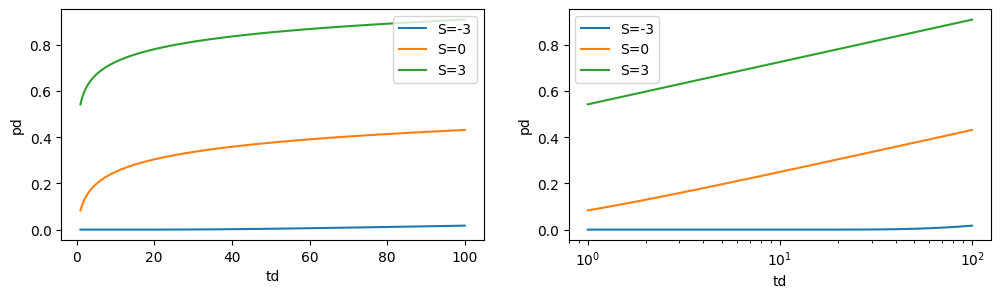

In [7]:
td_arr = np.logspace(0, 2, 100)
rd = 1
# при построении используем векторный расчет
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3))
for skin in [-3,0,3]:
    ax1.plot(td_arr, pd_line_source_ei(td_arr, rd, skin = skin), label = f'S={skin}' )
    ax2.plot(td_arr, pd_line_source_ei(td_arr, rd, skin = skin), label = f'S={skin}' )
#plt.title("Решение уравнения линейного стока для td = {}".format(td))
ax1.set_xlabel("td")
ax1.set_ylabel("pd")
ax2.set_xlabel("td")
ax2.set_ylabel("pd")
ax2.set_xscale('log')
ax1.legend()
ax2.legend()
plt.show()

### Давление от расстояния для произвольного момента времени в размерных координатах

скин-фактор = -3


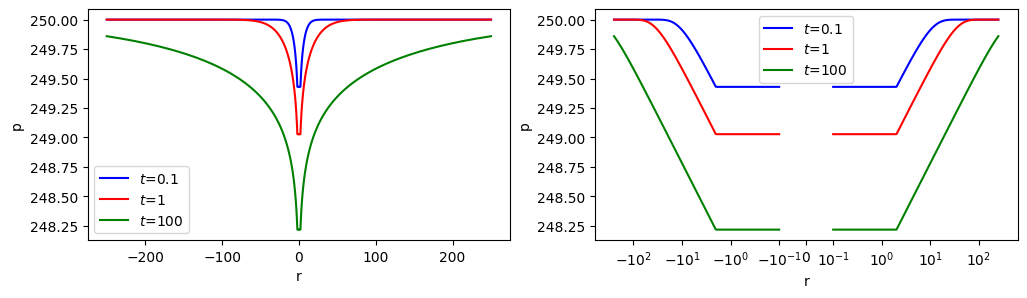

скин-фактор = 0


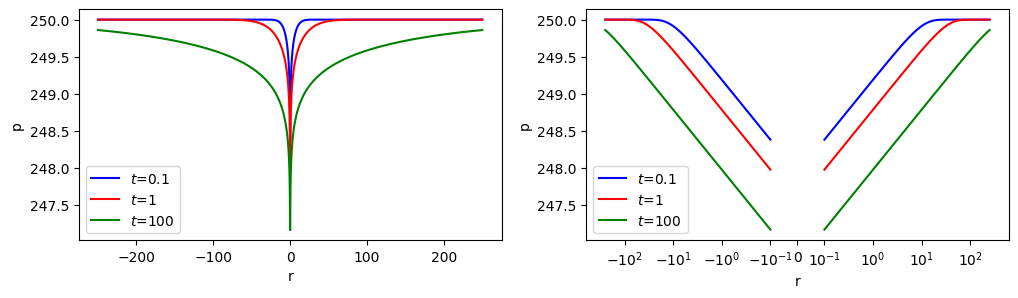

скин-фактор = 3


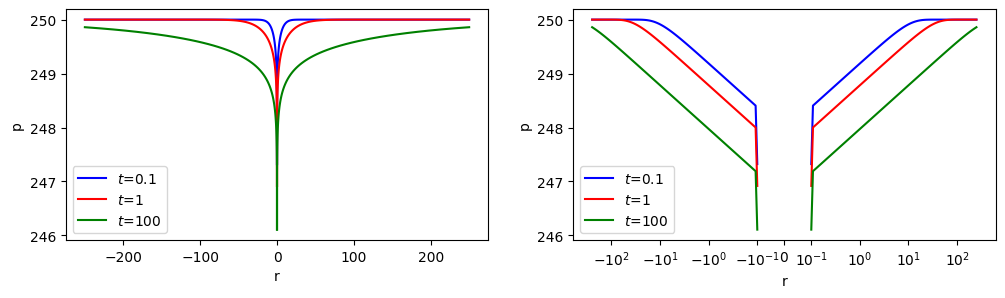

In [8]:
r_arr = np.logspace(np.log10(0.1), np.log10(250), 100)
clr = ['b', 'r', 'g']
res = ReservoirModel()
for skin in [-3, 0, 3]:
    print(f'скин-фактор = {skin}')
    res.skin = skin
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3))
    i = 0
    for t in [0.1, 1, 100]:
        # при построении используем векторный расчет
        ax1.plot(r_arr, p_line_source_ei_atma(t, r_arr, 10, res), clr[i], label = f'$t$={t}' )
        ax1.plot(-r_arr, p_line_source_ei_atma(t, r_arr, 10, res), clr[i])
        ax2.plot(r_arr, p_line_source_ei_atma(t, r_arr, 10, res), clr[i], label = f'$t$={t}' )
        ax2.plot(-r_arr, p_line_source_ei_atma(t, r_arr, 10, res), clr[i] )
        i = i + 1
    #plt.title("Решение уравнения линейного стока для td = {}".format(td))
    ax1.set_xlabel("r")
    ax1.set_ylabel("p")
    ax2.set_xlabel("r")
    ax2.set_ylabel("p")
    ax1.legend()
    ax2.legend()
    ax2.set_xscale('symlog', linthresh=0.1, linscale=0.5)
    plt.show()

### Забойное давление от времени

Для различных значений скин-фактора

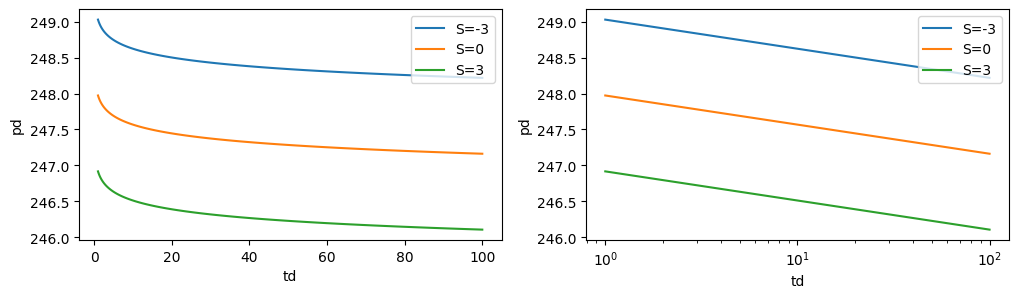

In [9]:
t_arr = np.logspace(0, 2, 100)
r = 0.1
res = ReservoirModel()
# при построении используем векторный расчет
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3))
for skin in [-3,0,3]:
    res.skin = skin
    ax1.plot(t_arr, p_line_source_ei_atma(t_arr, r, 10, res), label = f'S={skin}' )
    ax2.plot(t_arr, p_line_source_ei_atma(t_arr, r, 10, res), label = f'S={skin}' )
#plt.title("Решение уравнения линейного стока для td = {}".format(td))
ax1.set_xlabel("td")
ax1.set_ylabel("pd")
ax2.set_xlabel("td")
ax2.set_ylabel("pd")
ax2.set_xscale('log')
ax1.legend()
ax2.legend()
plt.show()

# 3. Радиус влияния


Нестационарное решение в безразмерных переменных
$$ 
p_D(r_D,t_D) = - \frac{q_D}{4 \pi } Ei \left(- \dfrac{ r_D^2}{4t_d} \right) 
$$

Для этих же безразмерных переменных, считая начальное давление равным давлению на контуре можно записать стационарное решение для движения в круговом пласте

$$
p_{D} =\dfrac{q_D}{2 \pi} \ln \dfrac{ r_{eD}}{ r_{D}}
$$

$$
p_{D} =\dfrac{q_D}{2 \pi} ( \ln  r_{eD} - \ln r_{D} )
$$

сравним это решение с логарифмической аппроксимацией (1)

$$
p_D(r_D,t_D) = - \frac{q_D}{4 \pi} \left[ \ln \left( \dfrac{ r_D^2}{4t_d} \right) +\gamma \right] 
$$

которое можно преобразовать к виду
$$
p_D(r_D,t_D) = - \frac{q_D}{2\pi} \ln r_D  + \frac{q_D}{4\pi} \left[ \ln(4t_D)   -\gamma \right]
$$

сравнивая со стационарным решением можно найти выражение безразмерного радиуса контура в зависимости от безразмерного времени
$$\ln r_{eD} = \frac{1}{2}(\ln(4t_D)-\gamma) $$

$$r_{eD} =  \sqrt { 4t_D e^{-\gamma} } $$

In [10]:
# оценим значение величины под корнем
print(4*np.exp(-0.57721566481))

2.2458379344731085


наконец получим
$$r_{eD} = \sqrt {2.2458 t_D} \tag{9}$$

это значение называют радиусом влияния скважины. Используя это значение для определенного момента времени можно получить стационарное распределение давления в системе хорошо приближающее решение линейного стока работающего в бесконечном пласте. Можно считать это расстояние за расстояние на которое распространяется влияние скважины.

достижение радиуса влияния внешних границ будет обуславливать начало перехода от неустановившегося режима фильтрации к режиму обусловленному влиянием границ - стационарному для границы постоянного давления или псевдоустановившемуся для границы непротекания.

In [11]:
def pd_ss(rd, r_ed=2500, qd=1, skin=0):
    # оценим приведенный радиус скважины
    rd_eff = np.exp(-skin) * np.heaviside(-skin, 0) + np.heaviside(skin, 1)
    # преобразуем входные радиусы в приведенные с учетом величины скин-фактора
    rd_calc = rd * np.heaviside(rd - rd_eff, 0) + np.exp(-skin) * np.heaviside(rd_eff - rd, 1)

    return qd / 2 / np.pi * (np.log(r_ed/rd_calc) )

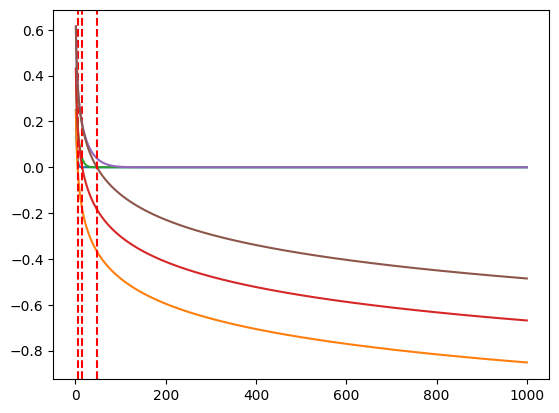

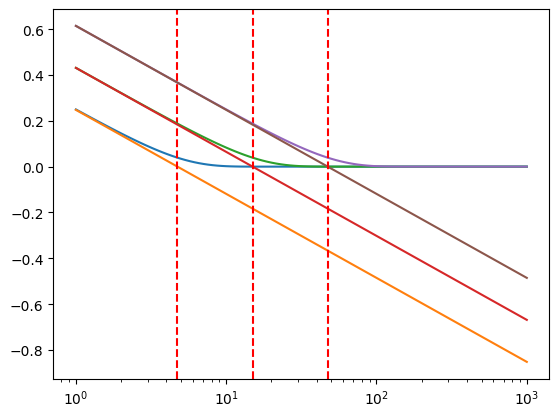

In [12]:
# зададим точки расстояний для отрисовки графика
rdl = np.logspace(0, 3 , 100)

# построим первый график в обычных координатах
for td in [10, 100, 1000]:
    plt.plot(rdl, pd_line_source_ei(td, rdl))
    
    red = (td*2.2458)**0.5
    plt.plot(rdl, pd_ss(rdl, red))
    plt.axvline( (2.2458 * td)**0.5, color='r', linestyle='--')
plt.show()

# построим второй график в полулогарифмических координатах
for td in [10, 100, 1000]:
    plt.plot(rdl, pd_line_source_ei(td, rdl, skin=-0))
    
    red = (td*2.2458)**0.5
    plt.plot(rdl, pd_ss(rdl, red, skin=-0))
    plt.axvline( (2.2458 * td)**0.5, color='r', linestyle='--')
plt.xscale('log')
plt.show()

# 4. Расчет кривой восстановления давления 

Один из самых простых примеров применения суперпозиции. Предполагаем, что добывающая скважина в однородном изотропном пласте запускается в момент времени `t=0` и работает `t_p_hr` часов, после чего останавливается. После остановки скважины забойное давление растет - и мы получим кривую восстановления давления.

Пусть решение задачи запуска скважины (падения давления) будет $P_D(t_D, r_D)$. Тогда решение для изменения давления при запуске и последующей остановки скважины можно представить в виде 
$$P_{bu.D}(t_D, t_{prod.D}, r_D) = P_D(t_D) - P_D(t_D-t_{prod.D}, r_D) \cdot \mathcal{H}(t_D-t_{prod.D}) $$

где
* $t_D$ - безразмерное время после запуска скважины,
* $t_{prod.D}$ - безразмерное время работы скважины после запуска
* $\mathcal{H}$ - ступенчатая [функция Хевисайда](https://ru.wikipedia.org/wiki/%D0%A4%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D1%8F_%D0%A5%D0%B5%D0%B2%D0%B8%D1%81%D0%B0%D0%B9%D0%B4%D0%B0) (в некоторых книгах обозначается как $\theta$)
* $P_D(t_D, r_D)$ - безразмерное давление - решение задачи запуска скважины (падения давления)
* $P_{bu.D}(t_D, t_{prod.D}, r_D)$ - безразмерное давление- решение задачи запуска скважины и последующей остановки скважины

Для проведения векторных расчетов в python удобно выражение с использованием функции Хевисайда

$$ \mathcal{H} = \begin{cases}0 & x < 0\\1 & x = 0\\1 & x > 0\end{cases}$$

Применение функции Хевисайда позволяет избежать в расчетных функциях применение условных операторов в явном виде для отдельных элементов входных массивов. Это потенциально ускоряет расчет. 

In [13]:
def pd_line_source_ei_build_up(td, td_prod, rd, qd=1, skin=0):
    """
    расчет давления для запуска и последующей остановки скважины (безразмерный)
    td - время после запуска
    td_p - время безразмерное - которое скважина работала до остановки
    rd - расстояния от скважины
    """
    
    # применение функции Хевисайда здесь делает расчет корректным
    # для входных векторов td
    return pd_line_source_ei(td, rd, qd, skin) - np.heaviside(td-td_prod,1) * pd_line_source_ei(td-td_prod, rd, qd, skin) 


def p_line_source_ei_build_up_atma_(t_hr, r_m, t_prod_hr, q_sm3day=1.0, res=None):
    """
    расчет давления для запуска и последующей остановки скважины
    t_hr - время после запуска, час
    t_prod_hr - время - которое скважина работала до остановки
    r_m - расстояния от скважины
    res - параметры пласта и скважины
    """
    
    # применение функции Хевисайда здесь делает расчет корректным
    # для входных векторов td
    if res == None: 
        res = ReservoirModel()
    return p_line_source_ei_atma(t_hr, r_m, q_sm3day, res) + np.heaviside(t_hr-t_prod_hr, 1) * (res.p_init_atma - p_line_source_ei_atma(t_hr-t_prod_hr, r_m, q_sm3day, res))

# можно определить функцию для кривой восстановления давления по другому

def p_line_source_ei_build_up_atma(t_hr, r_m, t_prod_hr, q_sm3day=1.0, res=None):
    """
    расчет давления для запуска и последующей остановки скважины
    t_hr - время после запуска, час
    t_prod_hr - время - которое скважина работала до остановки
    r_m - расстояния от скважины
    res - параметры пласта и скважины
    """

    if res is None:
        res = ReservoirModel()
    td = td_from_t(t_hr, res.k_mD, res.phi, res.mu_cP, res.ct_1atm, res.rw_m)
    td_prod = td_from_t(t_prod_hr, res.k_mD, res.phi, res.mu_cP, res.ct_1atm, res.rw_m)
    rd = rd_from_r(r_m, res.rw_m)
    qd = qd_from_q(q_sm3day)
    pd = pd_line_source_ei_build_up(td, td_prod, rd, qd, res.skin)
    return p_from_pd_atma(pd, res.k_mD, res.h_m, 1, res.b_m3m3, res.mu_cP, res.p_init_atma)



время работы скважины 24.00 часа, что соответсвует безразмерному времени 4320000.00


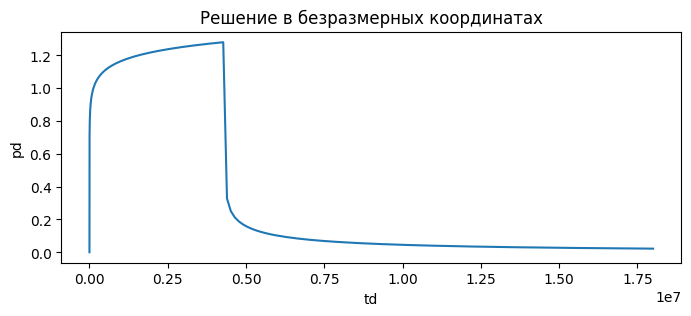

In [14]:
t_arr = np.logspace(-10, 2, 1000)
t_prod_hr = 24
k = 10   # проницаемость
q = 30   # дебит

# переведем размерный массив времени в безразмерные величины
# некоторые параметры можно было бы пропустить и оставить значения по умолчанию
# но для полноты приведем их в явном виде

td_arr = td_from_t(t_arr, k_mD=k, phi=0.2, mu_cP=1, ct_1atm=1e-05, rw_m=0.1)
td_prod = td_from_t(t_prod_hr, k_mD=k, phi=0.2, mu_cP=1, ct_1atm=1e-05, rw_m=0.1)

print('время работы скважины {:.2f} часа, что соответсвует безразмерному времени {:.2f}'.format(t_prod_hr, td_prod))

# для заданного массива безразмерных времен рассчитаем безразмерные давления
pd_arr = pd_line_source_ei_build_up(td_arr, td_prod, rd=1)

# построение графика
plt.rcParams["figure.figsize"] = (8,3)

plt.plot(td_arr, pd_arr)

plt.xlabel('td')
plt.ylabel('pd')
plt.title('Решение в безразмерных координатах')
plt.show()

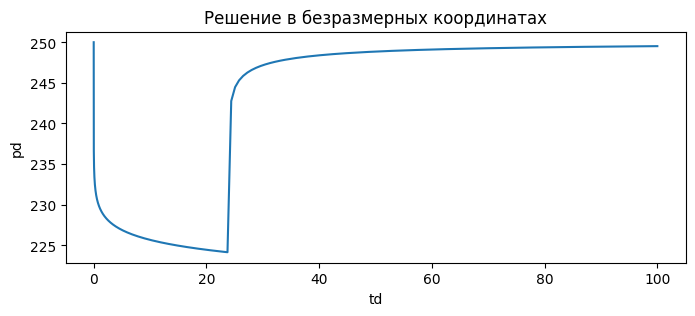

In [15]:
t_arr = np.logspace(-10, 2, 1000)
t_prod_hr = 24
k = 10   # проницаемость
q = 30   # дебит
res = ReservoirModel()
res.k_mD = k 

# переведем размерный массив времени в безразмерные величины
# некоторые параметры можно было бы пропустить и оставить значения по умолчанию
# но для полноты приведем их в явном виде

# для заданного массива безразмерных времен рассчитаем безразмерные давления
p_arr = p_line_source_ei_build_up_atma(t_arr, r_m=0.1, t_prod_hr=t_prod_hr, q_sm3day=100, res=res)

# построение графика
plt.rcParams["figure.figsize"] = (8,3)

plt.plot(t_arr, p_arr)

plt.xlabel('td')
plt.ylabel('pd')
plt.title('Решение в безразмерных координатах')
plt.show()

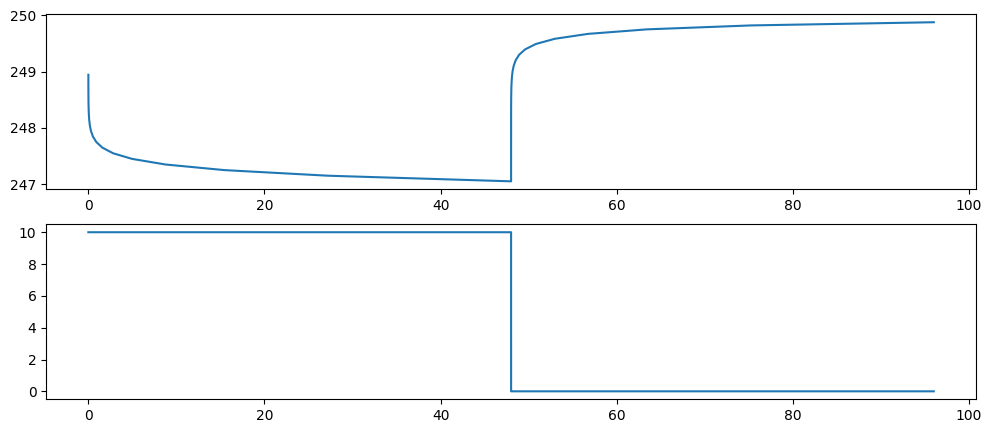

In [16]:
q = 10
t_p_hr = 48

t_list = np.logspace(np.log10(0.001), np.log10(t_p_hr), 20)
t_list_bu = np.concatenate([t_list, t_list + t_p_hr])

q_list = np.concatenate([np.full_like(t_list, q), np.full_like(t_list, 0)])

td_list = td_from_t(t_list_bu)
td_p = td_from_t(t_p_hr)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,5))
ax1.plot(t_list_bu, p_from_pd_atma(pd_line_source_ei_build_up(td_list, td_p, rd=1, qd=q)))
ax2.plot(t_list_bu, q_list)

## Построение графиков распределения давления в пласте при восстановлении давления

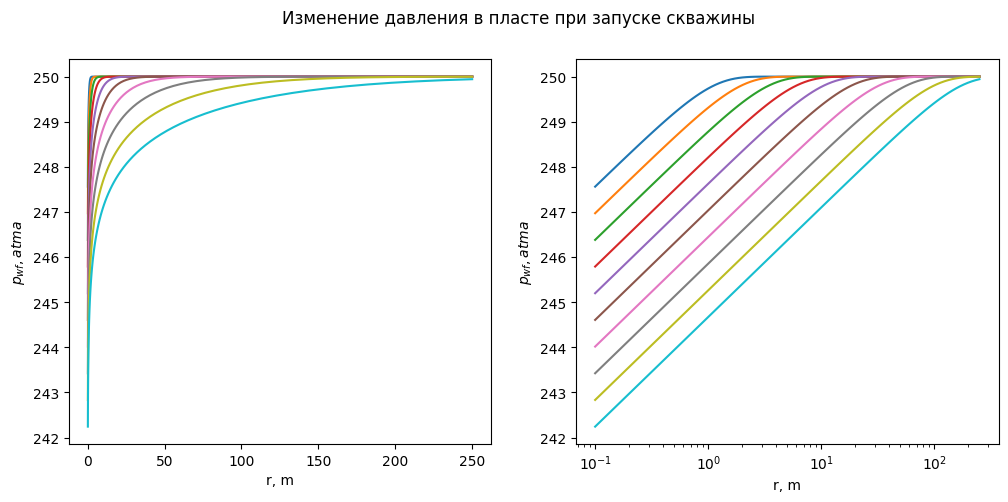

In [17]:
r_arr_m = np.logspace(np.log10(0.1), np.log10(250), 100)
t_arr_hr = np.logspace(np.log10(0.001), np.log10(24), 10)

t_prod_hr = 24
q_sm3day = 30

res = ReservoirModel()

tv, rv = np.meshgrid(t_arr_hr,r_arr_m)

p_arr_atma =p_line_source_ei_atma(tv, r_m=rv, q_sm3day=q_sm3day, res=res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = [12,5])
fig.suptitle('Изменение давления в пласте при запуске скважины')
ax1.plot(r_arr_m, p_arr_atma)
ax1.set_label(t_arr)
ax1.set_xlabel('r, m')
ax1.set_ylabel('$p_{wf}, atma$')

ax2.plot(r_arr_m, p_arr_atma)
ax2.set_xscale('log')
ax2.set_xlabel('r, m')
ax2.set_ylabel('$p_{wf}, atma$')
plt.show()

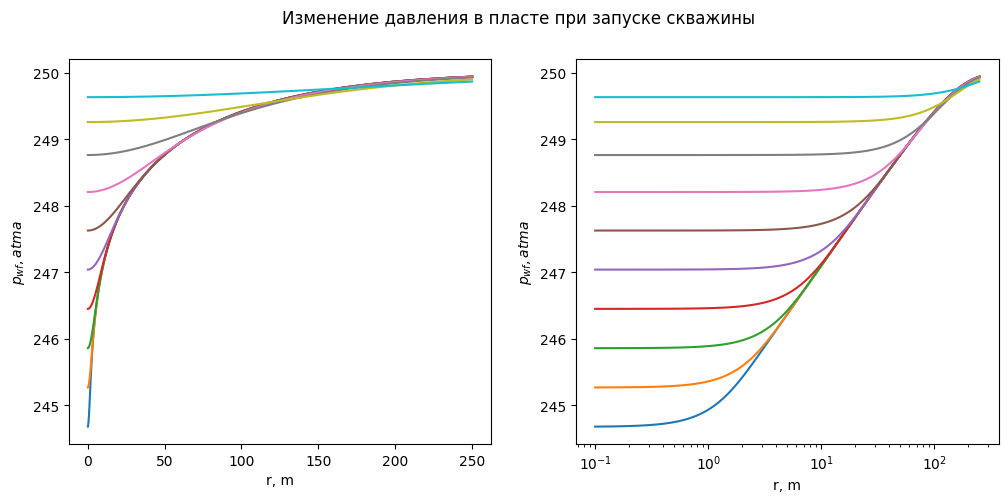

In [18]:
p_arr_bu_atma =p_line_source_ei_build_up_atma(tv + t_prod_hr, r_m=rv, t_prod_hr= t_prod_hr, q_sm3day=q_sm3day, res=res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = [12,5])
fig.suptitle('Изменение давления в пласте при запуске скважины')
ax1.plot(r_arr_m, p_arr_bu_atma)
ax1.set_label(t_arr)
ax1.set_xlabel('r, m')
ax1.set_ylabel('$p_{wf}, atma$')

ax2.plot(r_arr_m, p_arr_bu_atma)
ax2.set_xscale('log')
ax2.set_xlabel('r, m')
ax2.set_ylabel('$p_{wf}, atma$')
plt.show()

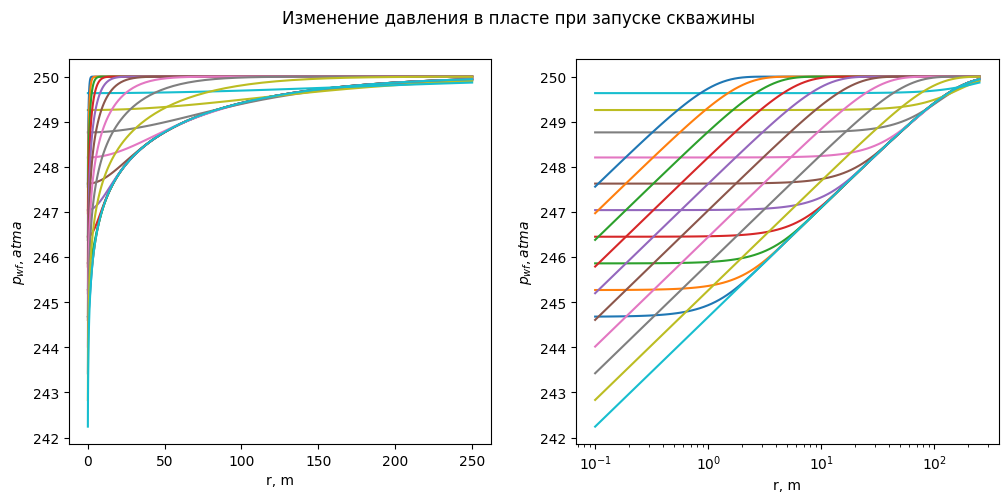

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = [12,5])
fig.suptitle('Изменение давления в пласте при запуске скважины')
ax1.plot(r_arr_m, p_arr_bu_atma)
ax1.plot(r_arr_m, p_arr_atma)
ax1.set_label(t_arr)
ax1.set_xlabel('r, m')
ax1.set_ylabel('$p_{wf}, atma$')

ax2.plot(r_arr_m, p_arr_bu_atma)
ax2.plot(r_arr_m, p_arr_atma)
ax2.set_xscale('log')
ax2.set_xlabel('r, m')
ax2.set_ylabel('$p_{wf}, atma$')
plt.show()

# 5. Суперпозиция
## Множественные запуски и остановки

Используя принцип суперпозиции, можем выписать выражение для изменения давления на скважине и вокруг нее для произвольного момента времени

$$p_{mr.D}(t_D, r_D) = \sum_i \left[ q_{D(i)}-q_{D(i-1)} \right] \cdot p_D\left(t_D-t_{D(i)}, r_D\right)\cdot \mathcal{H}(t_D-t_{D(i)})  $$

где

* $i$ - индекс значения дебита в таблице изменения дебитов
* $q_{D(i)}$ - безразмерный дебит с номером $i$, который стартует в момент времени $t_i$. Для первого момента времени $i$ дебит следующий перед ним считается равным нулю
* $t_{D(i)}$ - безразмерный момент времени - включения дебита с номером $i$
* $t_{D}$ - безразмерный момент времени для которого проводится расчет
* $\mathcal{H}$ - ступенчатая [функция Хевисайда](https://ru.wikipedia.org/wiki/%D0%A4%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D1%8F_%D0%A5%D0%B5%D0%B2%D0%B8%D1%81%D0%B0%D0%B9%D0%B4%D0%B0#:~:text=%D0%A4%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D1%8F%20%D0%A5%D0%B5%D0%B2%D0%B8%D1%81%D0%B0%D0%B9%D0%B4%D0%B0%20%D1%88%D0%B8%D1%80%D0%BE%D0%BA%D0%BE%20%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D1%83%D0%B5%D1%82%D1%81%D1%8F%20%D0%B2,%D0%B4%D0%BB%D1%8F%20%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%B8%20%D1%8D%D0%BC%D0%BF%D0%B8%D1%80%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B9%20%D1%84%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D0%B8%20%D1%80%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8F.)
* $p_D\left(t\right)$ - зависимость безразмерного давление от времени - решение задачи запуска скважины с постоянным единичным дебитом
* $p_{mr.D} $ - безразмерное давление $P_{mr.D}(t_D, r_D)$ учитывающее историю изменения дебитов скважины

In [20]:
# создадим историю изменения дебитов 

t_history = np.array([ 0., 2., 24. ], dtype=np.float64) 
q_history = np.array([10., 5., 0.], dtype=np.float64)

# массивы должны быть одной и той же длины

In [21]:
def pd_superposition(td, td_hist, qd_hist, rd):
    """
    расчет безразмерного давления для последовательности безразмерных дебитов
    td -  время расчета после запуска, безразмерное
    td_hist - массив времен изменения режимов работы скважин, безразмерное
    qd_hist - массив дебитов установленных после изменения режима работы, безразмерное
    """
    # принудительно добавим нули во входные массивы, чтобы учесть запуск скважины
    qdh = np.hstack([0, qd_hist])
    tdh = np.hstack([0, td_hist])
    # построим дебиты виртуальных скважин - разности реальных дебитов при переключении
    delta_qd = np.hstack([0, np.diff(qdh)])
    # референсный безразмерный дебит это 1
    
    # векторная магия - время может быть вектором и переключения дебитов тоже вектор
    # надо организовать сумму по временам, каждая из котороых сумма по переключениям
    # делаем при помощи расчета meshgrid и поиска накопленных сумм
    qd_v, td_v =np.meshgrid(delta_qd, td)
    # используем куммулятивную сумму numpy для того что суммировать результаты
    dpd = np.cumsum(qd_v * pd_line_source_ei((td_v - tdh), rd) * np.heaviside((td_v - tdh), 1),1 )
    # последний столбец - полная сумма, которая нужна в качестве результата
    return dpd[:,-1]


def q_superposition(t, t_hist, q_hist):
    """
    расчет давления для запуска и последующей остановки скважины
    t_hr - время после запуска в часах
    t_hist_hr - массив времен изменения режимов работы скважин
    q_hist_sm3day - массив дебитов установленных после изменения режима работы
    """
    def interpolate_constant(x, xp, yp):
        indices = np.searchsorted(xp, x, side='right')
        y = np.concatenate(([0], yp))
        return y[indices]

    q=[]
    for ti in t:
        q.append(interpolate_constant(ti, t_hist, q_hist))
    return q

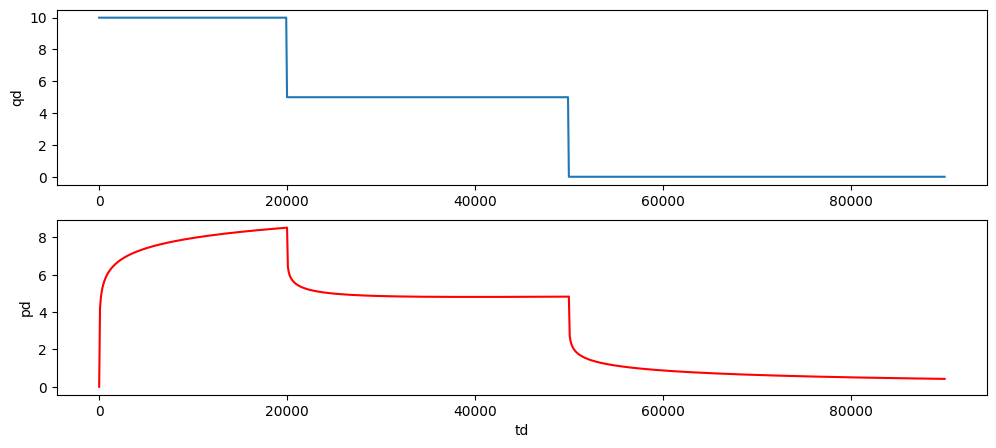

In [22]:
td_arr = np.linspace(1e-3, 9e4, 1000)


td_history = np.array([ 0., 2e4, 5e4 ], dtype=np.float64) 
qd_history = np.array([10., 5., 0.], dtype=np.float64)

plt.rcParams["figure.figsize"] = (12,5)
fig, (ax1, ax2) = plt.subplots(2,1)

ax1.plot(td_arr, q_superposition(td_arr, td_history, qd_history)) 
ax2.plot(td_arr, pd_superposition(td_arr, td_history, qd_history, rd=1), color='red') 
ax2.set_xlabel('td')
ax1.set_ylabel('qd')
ax2.set_ylabel('pd')
plt.show()

In [23]:
def p_superposition_atma(t_hr, t_hist_hr, q_hist_sm3day,
                         k_mD=10, h_m=10, b_m3m3=1.2, mu_cP=1, pi_atma=250, phi=0.2, 
                         ct_1atm=1e-05, rw_m=0.1):
    """
    расчет давления для запуска и последующей остановки скважины
    t_hr - время после запуска в часах
    t_hist_hr - массив времен изменения режимов работы скважин
    q_hist_sm3day - массив дебитов установленных после изменения режима работы
    k_mD=10 - проницаемость, мД, 
    h_m=10 - мощность пласта, м, 
    b_m3m3=1.2 - объемный коэффициент, м3/м3, 
    mu_cP=1 - вязкость нефти, сП, 
    pi_atma=250 - начальное давление, атм, 
    phi=0.2 - пористость, доли единиц, 
    ct_1atm=1e-05 - общая сжимаемость, 1/атм, 
    rw_m=0.1 - радиус скважины
    """
    q_ref=1.
    return p_from_pd_atma(pd_superposition(td_from_t(t_hr, k_mD=k_mD, phi=phi, mu_cP=mu_cP, 
                                                     ct_1atm=ct_1atm, rw_m=rw_m),
                                           td_from_t(t_hist_hr, k_mD=k_mD, phi=phi, mu_cP=mu_cP, 
                                                     ct_1atm=ct_1atm, rw_m=rw_m),
                                           q_hist_sm3day / q_ref, 
                                           1), 
                          k_mD=10, h_m=10, q_ref_sm3day=q_ref, b_m3m3=1.2, mu_cP=1, pi_atma=250)



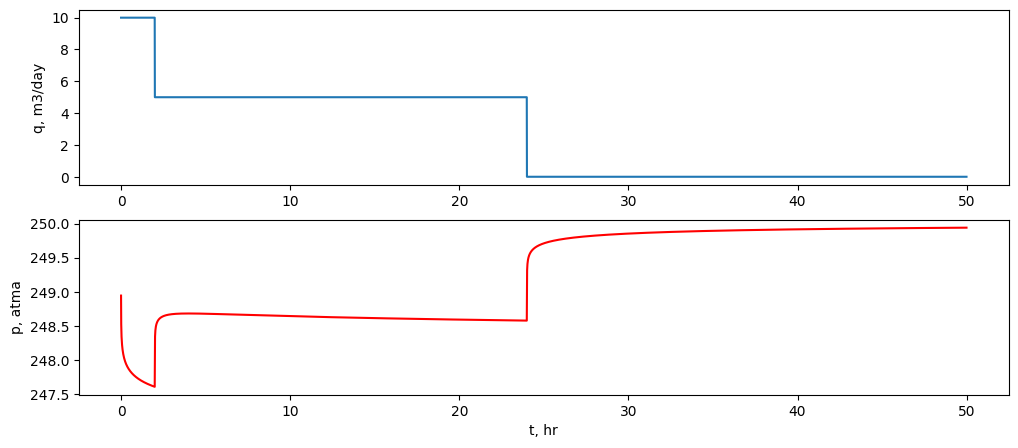

In [24]:
# создадим историю изменения дебитов 

t_history = np.array([ 0., 2., 24. ], dtype=np.float64) 
q_history = np.array([10., 5., 0.], dtype=np.float64)

# массивы должны быть одной и той же длины

t_arr = np.arange(1e-3, 50, 1e-2)
plt.rcParams["figure.figsize"] = (12,5)

fig, (ax1, ax2) = plt.subplots(2,1)
ax1.plot(t_arr, q_superposition(t_arr, t_history, q_history)) 
ax2.plot(t_arr, p_superposition_atma(t_arr, t_history, q_history), color='red') 
ax2.set_xlabel('t, hr')
ax1.set_ylabel('q, m3/day')
ax2.set_ylabel('p, atma')
plt.show()

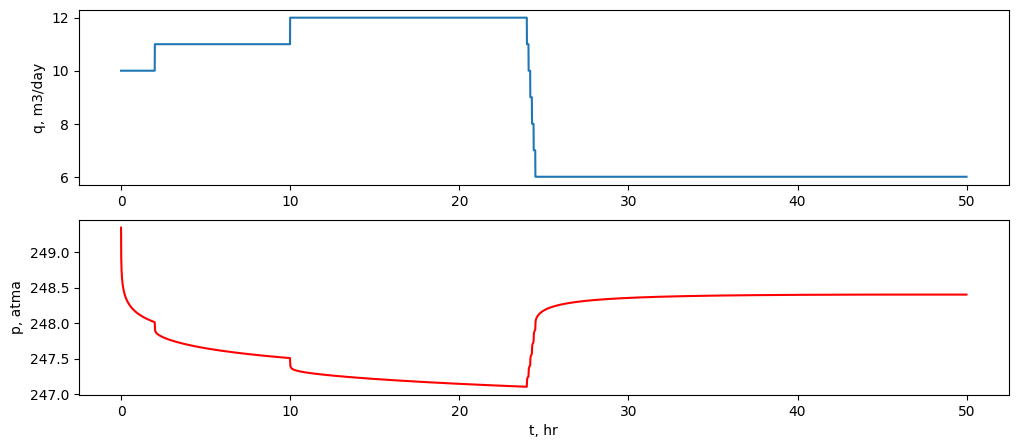

In [25]:

t_history = np.array([0, 2, 10, 24, 24.1,24.2,24.3,24.4,24.5 ])
q_history = np.array([10, 11, 12, 11, 10, 9, 8, 7, 6])

plt.rcParams["figure.figsize"] = (12,5)

fig, (ax1, ax2) = plt.subplots(2,1)
ax1.plot(t_arr, q_superposition(t_arr, t_history, q_history)) 
ax2.plot(t_arr, p_superposition_atma(t_arr, t_history, q_history, 1), color='red') 
ax2.set_xlabel('t, hr')
ax1.set_ylabel('q, m3/day')
ax2.set_ylabel('p, atma')
plt.show()

## Случай для линейного изменения дебита

In [26]:
import sympy 

In [27]:
rd, td, qd = sympy.symbols('r_D t_D q_D')
# запишем решение в символьном виде для постоянного дебита
eq = -qd/2 * sympy.Ei(-rd **2 / 4 / td)
display(eq)

-q_D*Ei(-r_D**2/(4*t_D))/2

для линейно меняющегося дебита $\theta_D t_D$ решение можно представить как интеграл

$$p_D = \int_0^{t_D}{- \frac{\theta_D}{2} Ei \left(- \dfrac{ r_D^2}{4t_d} \right) dt_D} \tag{8}$$

In [28]:
# проинтегрируем решение по времени
eq1 = sympy.integrate(eq, td)
display(eq1)

-q_D*(r_D**2*Ei(-r_D**2/(4*t_D))/4 + t_D*Ei(-r_D**2/(4*t_D)) + t_D*exp(-r_D**2/(4*t_D)))/2



Для линейно меняющегося дебита во времени (как и для любой другой зависимости) надо решение проинтегрировать по времени (надо бы подробнее расписать - сделать это позже, например как у Щелкачева в основах нестационарной фильтрации на стр 321).

Для линейной зависимости дебита от времени 
$$
Q_D = \theta \cdot t_D \tag{9}
$$
можно получить выражение

$$
p_D(r_D,t_D, \theta) =-\frac{\theta t_D }{2} \left[ \left( 1+ \frac{r_D^2}{4 t_D} \right) Ei \left(- \dfrac{r_D^2}{4t_D} \right) + e^{-\dfrac{r_D^2}{4t_D}} \right] \tag{10}
$$

где $\theta$ - скорость изменения дебита.

Для таблично заданных дебитов и времен можно оценить 

$$
\theta_{(i)} = \dfrac{Q_{D(i)}-Q_{D(i-1)}}{t_{D(i)} - t_{D(i-1)} } \tag{11}
$$

Cравните формулу (11) с формулой (9.68) в книге Щелкачева "Основы неустановившейся фильтрации"

Тогда, используя принцип суперпозиции, можем выписать выражение для изменения давления на скважине и вокруг нее для произвольного момента времени

$$
P_{mr.D}(t_D, r_D) = \sum_i  p_D\left(t_D-t_{D(i)}, r_D, \theta_{(i+1)} - \theta_{(i)}\right)\cdot \mathcal{H}(t_D-t_{D(i)}) \tag{12}
$$

где

* $i$ - индекс значения дебита в таблице изменения дебитов
* $\theta_{(i)}$ - изменение безразмерного дебита относительно безразмерного времени (14.4) 
* $t_{D(i)}$ - безразмерный момент времени - включения дебита с номером $i$
* $t_{D}$ - безразмерный момент времени для которого проводится расчет
* $\mathcal{H}$ - ступенчатая [функция Хевисайда](https://ru.wikipedia.org/wiki/%D0%A4%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D1%8F_%D0%A5%D0%B5%D0%B2%D0%B8%D1%81%D0%B0%D0%B9%D0%B4%D0%B0#:~:text=%D0%A4%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D1%8F%20%D0%A5%D0%B5%D0%B2%D0%B8%D1%81%D0%B0%D0%B9%D0%B4%D0%B0%20%D1%88%D0%B8%D1%80%D0%BE%D0%BA%D0%BE%20%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D1%83%D0%B5%D1%82%D1%81%D1%8F%20%D0%B2,%D0%B4%D0%BB%D1%8F%20%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%B8%20%D1%8D%D0%BC%D0%BF%D0%B8%D1%80%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B9%20%D1%84%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D0%B8%20%D1%80%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8F.)
* $p_D\left(t\right)$ - зависимость безразмерного давление от времени - решение задачи запуска скважины с постоянным единичным дебитом
* $P_{mr.D} $ - безразмерное давление $P_{mr.D}(t_D, r_D)$ учитывающее историю изменения дебитов скважины

следует обратить внимание, при суперпозиции скорость изменения дебита вычисляется как $\theta{i+1)} - \theta{i)}$.  при реализации расчета необходимо предусмотреть, чтобы для первого и последнего шага расчет прошел корректно. Для этого можно, например, добавить к массивам дебитов и времени дополнительный значения в начале и в конце массивов соответствующие постоянным значениям дебита. 

Также надо учитывать, что в приведенном выражении массивы должны начинаться со значений $Q_D=0$



In [29]:
# Решение линейного стока уравнения фильтрации
def pd_lin_ei(td, rd=1, dqd_dtd=1):
    """
    Решение линейного стока уравнения фильтрации
    rd - безразмерное расстояние
    td - безразмерное время
    """
    # при расчете убедимся, что td=0 не повлияет на расчет, 
    # даже если td массив и нулевой только один элемент
    td = np.array(td, dtype = float)
    pd =  (1 + rd**2/4/td) * (-sp.expi(-rd**2 / 4 /td)) - np.exp(-rd**2 / 4 /td)
    return dqd_dtd * td * pd / 2

In [30]:
def pd_superposition_lin(td, td_hist, qd_hist):
    """
    расчет безразмерного давления для последовательности безразмерных дебитов
    td -  время расчета после запуска, безразмерное
    td_hist - массив времен изменения режимов работы скважин, безразмерное
    qd_hist - массив дебитов установленных после изменения режима работы, безразмерное
    """
    # принудительно добавим нули во входные массивы, чтобы учесть запуск скважины
    qdh = np.hstack([qd_hist])
    tdh = np.hstack([td_hist])
    # построим дебиты виртуальных скважин - разности реальных дебитов при переключении
    delta_qd = np.hstack([np.diff(qdh),0])
    delta_td = np.hstack([np.diff(tdh),1])
    
    dq_dt = delta_qd / delta_td
    dq_dt = np.diff(np.hstack([0, delta_qd / delta_td]))
    
    # референсный безразмерный дебит это 1
    
    # векторная магия - время может быть вектором и переключения дебитов тоже вектор
    # надо организовать сумму по временам, каждая из котороых сумма по переключениям
    # делаем при помощи расчета meshgrid и поиска накопленных сумм
    qd_v, td_v =np.meshgrid(delta_qd, td)
    
    dpd = np.cumsum(pd_lin_ei((td_v - tdh), dqd_dtd=dq_dt) * np.heaviside((td_v - tdh), 1),1 )

    return dpd[:,-1]

def p_superposition_lin_atma(t_hr, t_hist_hr, q_hist_sm3day,
                         k_mD=10, h_m=10, b_m3m3=1.2, mu_cP=1, pi_atma=250, phi=0.2, 
                         ct_1atm=1e-05, rw_m=0.1):
    """
    расчет давления для запуска и последующей остановки скважины
    t_hr - время после запуска в часах
    t_hist_hr - массив времен изменения режимов работы скважин
    q_hist_sm3day - массив дебитов установленных после изменения режима работы
    k_mD=10 - проницаемость, мД, 
    h_m=10 - мощность пласта, м, 
    b_m3m3=1.2 - объемный коэффициент, м3/м3, 
    mu_cP=1 - вязкость нефти, сП, 
    pi_atma=250 - начальное давление, атм, 
    phi=0.2 - пористость, доли единиц, 
    ct_1atm=1e-05 - общая сжимаемость, 1/атм, 
    rw_m=0.1 - радиус скважины
    """
    q_ref=1.
    return p_from_pd_atma(pd_superposition_lin(td_from_t(t_hr, k_mD=k_mD, phi=phi, mu_cP=mu_cP, 
                                                     ct_1atm=ct_1atm, rw_m=rw_m),
                                               td_from_t(t_hist_hr, k_mD=k_mD, phi=phi, mu_cP=mu_cP, 
                                                     ct_1atm=ct_1atm, rw_m=rw_m),
                                               q_hist_sm3day / q_ref), 
                          k_mD=10, h_m=10, q_ref_sm3day=q_ref, b_m3m3=1.2, mu_cP=1, pi_atma=250)


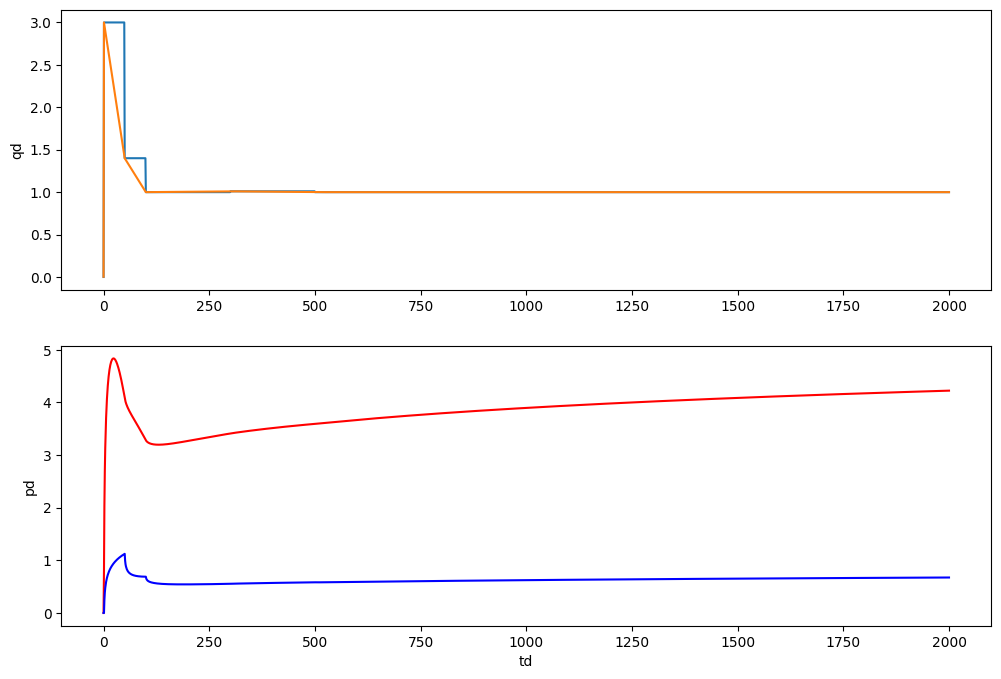

In [31]:
td_arr = np.linspace(1e-3, 2000, 2000)


td_history = np.array([0., 1, 50, 100, 300, 500 ], dtype=np.float64) 
qd_history = np.array([0., 3, 1.4, 1.0, 1.01, 1], dtype=np.float64)

plt.rcParams["figure.figsize"] = (12,8)
fig, (ax1, ax2) = plt.subplots(2,1)

ax1.plot(td_arr, q_superposition(td_arr, td_history, qd_history)) 
ax1.plot(td_arr, np.interp(td_arr, td_history, qd_history)) 
ax2.plot(td_arr, pd_superposition_lin(td_arr, td_history, qd_history), color='red') 
ax2.plot(td_arr, pd_superposition(td_arr, td_history, qd_history, rd=1), color='blue') 
ax2.set_xlabel('td')
ax1.set_ylabel('qd')
ax2.set_ylabel('pd')
plt.show()

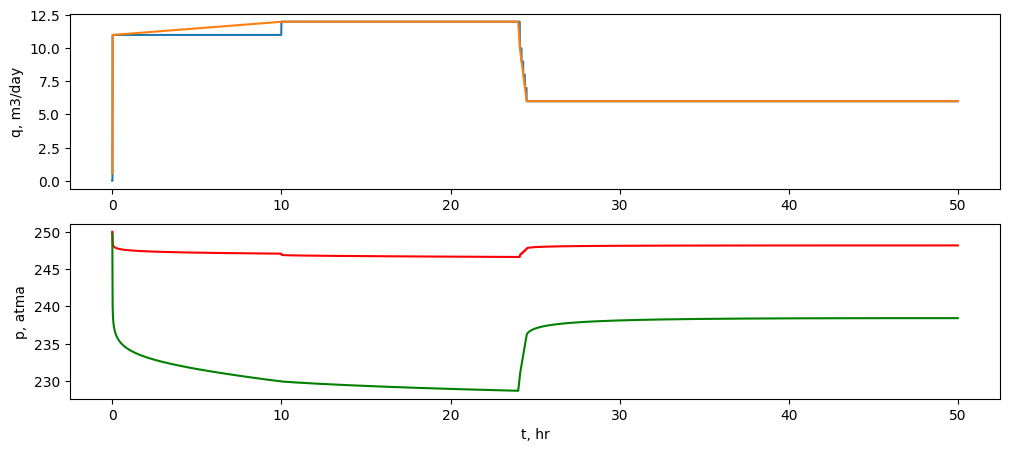

In [32]:
t_history = np.array([0, .02, 10, 24, 24.1,24.2,24.3,24.4,24.5 ])
q_history = np.array([0, 11, 12, 12, 10, 9, 8, 7, 6])

plt.rcParams["figure.figsize"] = (12,5)

fig, (ax1, ax2) = plt.subplots(2,1)
ax1.plot(t_arr, q_superposition(t_arr, t_history, q_history)) 
ax1.plot(t_arr, np.interp(t_arr, t_history, q_history)) 
ax2.plot(t_arr, p_superposition_atma(t_arr, t_history, q_history), color='red') 
ax2.plot(t_arr, p_superposition_lin_atma(t_arr, t_history, q_history), color='green') 
ax2.set_xlabel('t, hr')
ax1.set_ylabel('q, m3/day')
ax2.set_ylabel('p, atma')
plt.show()

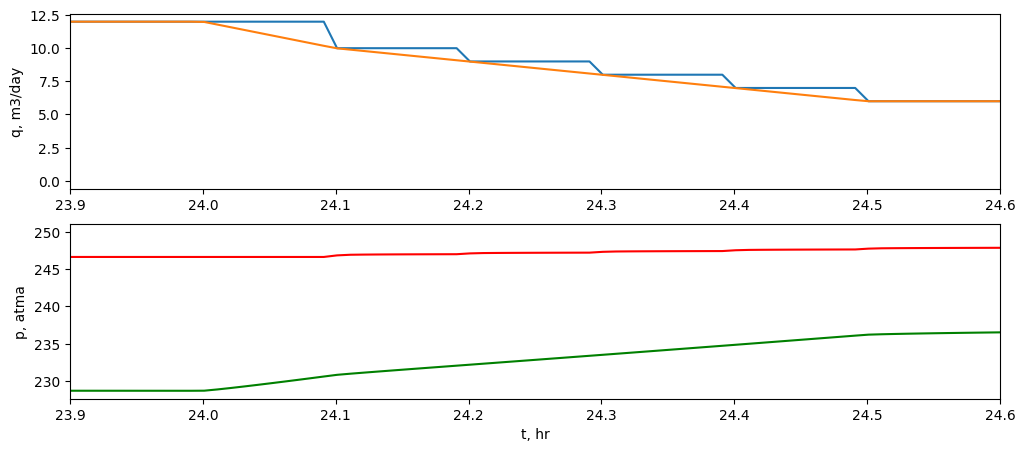

In [33]:
t_history = np.array([0, .02, 10, 24, 24.1,24.2,24.3,24.4,24.5 ])
q_history = np.array([0, 11, 12, 12, 10, 9, 8, 7, 6])

plt.rcParams["figure.figsize"] = (12,5)

fig, (ax1, ax2) = plt.subplots(2,1)
ax1.plot(t_arr, q_superposition(t_arr, t_history, q_history)) 
ax1.plot(t_arr, np.interp(t_arr, t_history, q_history)) 
ax2.plot(t_arr, p_superposition_atma(t_arr, t_history, q_history), color='red') 
ax2.plot(t_arr, p_superposition_lin_atma(t_arr, t_history, q_history), color='green') 
ax2.set_xlabel('t, hr')
ax1.set_ylabel('q, m3/day')
ax2.set_ylabel('p, atma')
ax1.set_xlim([23.9,24.6])
ax2.set_xlim([23.9,24.6])
plt.show()

### 4 Задания для самостоятельной работы 

Для совершенствования навыков работы с python выполните следующие задания:

1. Постройте решение для постоянного дебита. Аппрокимируйте получившуюся зависимость забойного давления от времени как кусочно линейную функцию и восстановите по ней дебиты используя решения для постоянного (или линейно меняющегося) дебита. Сравните получившееся решение с исходным.
2. Постройте решение для квадратично и кубично меняющегося дебита.
3. Построете решение для дебита изменяющегося как кубический сплайн.

## Интергал Дюамеля

Решение для произвольной истории изменения дебита, выраженной в виде гладкой функции $q_D(t_D)$ можно выразить в виде интеграла 

$$
p_D(t_D) = q_D(0) p_D(t_D) + \int_0^{t_D} \frac{dq_D(\tau)}{d\tau} p_D(t_D- \tau) d\tau
$$

где

- $t_D$ - безразмерное время для которого проводится расчет
- $p_D(t_D)$ - решение задачи для запуска скважины с единичным дебитом $q_D=1$
- $\tau$ - переменная интегрирования

In [34]:
# используем функцию интегрирования из scipy
from scipy.integrate import quad

# генератор производной для произвольной функции f(x)
def make_diff(f):
    def diff(x, dx=0.01):
        return (f(x+dx) - f(x-dx)) / 2 / dx
    return diff

проверим, как работет производная

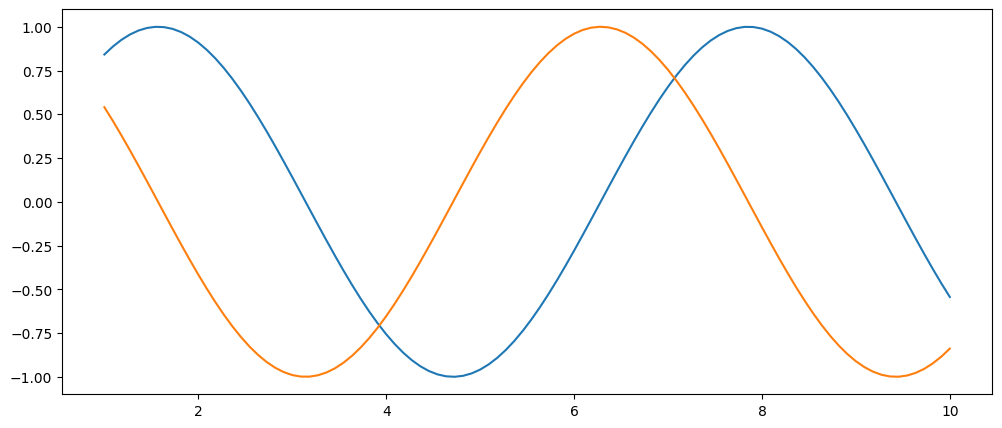

In [39]:
def f(x):
    return np.sin(x)

df = make_diff(f)

x = np.linspace(1, 10, 100)

plt.plot(x, f(x))
plt.plot(x, df(x))
plt.show()

In [35]:
def pd_super(td, fqd, rd=1):
    dfqd = make_diff(fqd)
    def integrand(tau):
        return dfqd(tau) * pd_line_source_ei(td-tau, rd=rd, qd=1) 
    return quad(integrand, 0, td)[0]

def pd_super_vectorized(td, fqd, rd=1):
    dfqd = make_diff(fqd)
    
    def single_calculation(td_val):
        def integrand(tau):
            return dfqd(tau) * pd_line_source_ei(td_val - tau, rd=rd, qd=1)
        return quad(integrand, 0, td_val)[0]
    
    vectorized_func = np.vectorize(single_calculation)
    return vectorized_func(td)

In [36]:
def piecewise_func(x):

    def f1(x): return x/1000      # x < 0
    def f2(x): return 10         # 0 <= x < 1  
    def f3(x): return 10      # x >= 1
    
    conditions = [
        x < 10000,           # condition for f1
        (x >= 10000) & (x < 50000),  # condition for f2
        x >= 50000           # condition for f3
    ]
    
    functions = [f1, f2, f3]
    
    return np.piecewise(x, conditions, functions)

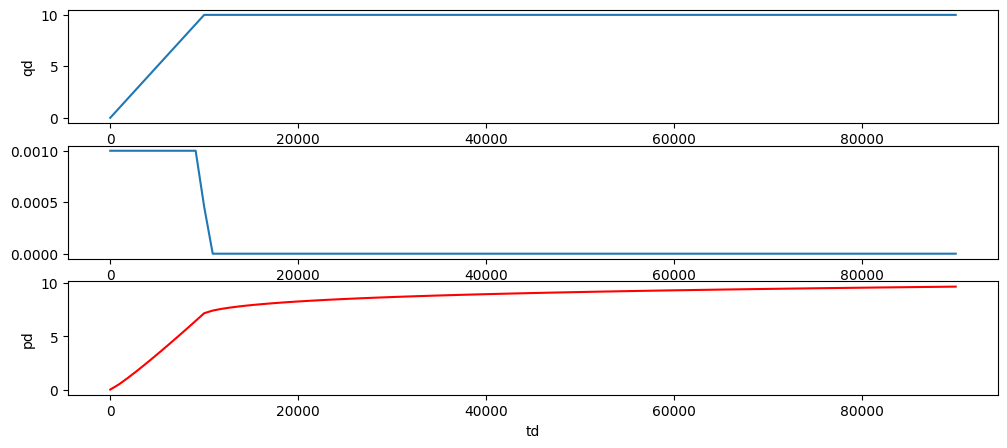

In [37]:
td_arr = np.linspace(1e-3, 9e4, 100)


plt.rcParams["figure.figsize"] = (12,5)
fig, (ax1, ax2, ax3) = plt.subplots(3,1)

def fq(td):
    return piecewise_func(td) # (np.sin(td/4000) ) * 10
dfq = make_diff(fq)

ax1.plot(td_arr, fq(td_arr) ) 
ax2.plot(td_arr, dfq(td_arr) )
ax3.plot(td_arr, pd_super_vectorized(td_arr, fq), color='red') 
ax3.set_xlabel('td')
ax1.set_ylabel('qd')
ax3.set_ylabel('pd')
plt.show()

# 3 Задания для самостоятельной работы <a class="anchor" id="363"></a>

Для совершенствования навыков работы с python выполните следующие задания:

1. Постройте графики распределения давления в пласте в размерном виде
2. Исследуйте как зависит радиус влияния скважины от проницаемости и других параметров. Какие характерные величины будут для разных условий